# Tic-Tac-Toe with Q-Learning

## Problem Statement

Can a computer **learn** to play tic-tac-toe without being told the rules explicitly? Instead of hard-coding a strategy, we use **Q-learning** — a model-free reinforcement learning algorithm — to let an agent discover a winning policy purely through trial and error.

The agent (playing as X) repeatedly plays games against a random opponent, receives rewards for winning or losing, and gradually builds a table of "how good is each move in each situation". After enough games, it learns to play near-optimally.

## What is Q-Learning?

Q-learning maintains a **Q-table**: a lookup table where each entry Q(s, a) estimates the *long-run reward* of taking action *a* in state *s*. After every move the agent updates its estimate using the **Bellman equation**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \Big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\Big]$$

- **α** (learning rate) — how quickly new information overwrites old estimates  
- **γ** (discount factor) — how much future rewards are worth relative to immediate ones  
- **r** — the reward received after the action  
- **s'** — the next state  

## Methodology

1. Build a minimal `TicTacToe` environment: board state, move validation, win detection
2. Implement a `QLearningAgent` with a Q-table, epsilon-greedy action selection, and a Bellman update
3. Train the agent over 50,000 episodes against a random opponent, decaying exploration over time
4. Plot win/draw/loss rates during training to visualise the learning curve
5. Evaluate the trained agent greedily (no exploration) over 1,000 games
6. Watch the agent play a full game move-by-move

---
## 1. Imports & Setup

In [ ]:
import random
import warnings
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. The Environment

We model tic-tac-toe as a standard **reinforcement learning environment** with three concepts:

| Concept | Representation |
|---|---|
| **State** | A length-9 tuple — one cell per board square (row-major order) |
| **Cell values** | `0` = empty, `1` = X (agent), `2` = O (opponent) |
| **Action** | An integer 0–8 selecting which cell to play |

The board indices look like this:
```
 0 | 1 | 2
-----------
 3 | 4 | 5
-----------
 6 | 7 | 8
```

`step(action, player)` applies a move and returns `(new_state, reward, done)`:
- **+1** if the moving player wins
- **−1** if the moving player loses (shouldn't happen mid-move, but used for delayed signals)
- **+0.5** for a draw
- **0** otherwise (game continues)

In [ ]:
class TicTacToe:
    """Minimal tic-tac-toe environment."""

    WINNING_LINES = [
        (0, 1, 2), (3, 4, 5), (6, 7, 8),  # rows
        (0, 3, 6), (1, 4, 7), (2, 5, 8),  # columns
        (0, 4, 8), (2, 4, 6),             # diagonals
    ]

    def reset(self):
        """Clear the board and return the initial state."""
        self.board = [0] * 9
        return tuple(self.board)

    def available_actions(self):
        """Return indices of empty cells."""
        return [i for i, v in enumerate(self.board) if v == 0]

    def is_winner(self, player):
        """Check whether `player` (1 or 2) has three in a row."""
        return any(
            self.board[a] == self.board[b] == self.board[c] == player
            for a, b, c in self.WINNING_LINES
        )

    def step(self, action, player):
        """
        Apply `action` for `player`. Returns (next_state, reward, done).
        Reward is from the perspective of `player`.
        """
        self.board[action] = player
        state = tuple(self.board)

        if self.is_winner(player):
            return state, 1.0, True

        if not self.available_actions():   # board full → draw
            return state, 0.5, True

        return state, 0.0, False

    def render(self, last_action=None):
        """Print the board. Highlights the last played cell with brackets."""
        symbols = {0: '.', 1: 'X', 2: 'O'}
        rows = []
        for row in range(3):
            cells = []
            for col in range(3):
                idx = row * 3 + col
                sym = symbols[self.board[idx]]
                cells.append(f'[{sym}]' if idx == last_action else f' {sym} ')
            rows.append('|'.join(cells))
        print('\n'.join(rows))
        print()

In [ ]:
# Quick sanity check — create a board, play two moves, render
env = TicTacToe()
env.reset()
env.step(4, 1)   # X takes the centre
env.step(0, 2)   # O takes the top-left
env.render(last_action=0)
print('Available actions:', env.available_actions())

[O]| . | . 
 . | X | . 
 . | . | . 

Available actions: [1, 2, 3, 5, 6, 7, 8]


---
## 3. The Q-Learning Agent

The agent stores all it knows in a single **Q-table** — a dictionary mapping every visited state to an array of 9 Q-values (one per board cell). Unseen states default to all-zeros.

### Action selection — ε-greedy

The agent balances **exploration** (trying random moves to discover new situations) and **exploitation** (picking the move with the highest Q-value):

- With probability **ε**: pick a random *valid* action  
- With probability **1 − ε**: pick the *valid* action with the highest Q-value  

ε starts at 1.0 (pure exploration) and decays toward 0.05 as training progresses, so the agent gradually shifts from exploring to exploiting.

### Q-table update

After each move the agent applies the Bellman equation to nudge Q(s, a) toward the observed return:

```
Q(s, a) += α × (r + γ × max Q(s', a') − Q(s, a))
```

If the game is over, the future term `γ × max Q(s', a')` is zero — only the immediate reward matters.

In [ ]:
class QLearningAgent:
    def __init__(
        self,
        alpha=0.1,          # learning rate
        gamma=0.95,         # discount factor
        epsilon=1.0,        # initial exploration probability
        epsilon_decay=0.9999,
        epsilon_min=0.05,
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        # Default Q-values are 0 for every (state, action) pair
        self.q_table = defaultdict(lambda: np.zeros(9))

    def choose_action(self, state, available):
        """
        ε-greedy action selection restricted to `available` cells.
        """
        if random.random() < self.epsilon:
            return random.choice(available)          # explore

        q_values = self.q_table[state].copy()
        # Mask invalid actions so they are never chosen greedily
        mask = np.full(9, -np.inf)
        mask[available] = q_values[available]
        return int(np.argmax(mask))                  # exploit

    def update(self, state, action, reward, next_state, next_available, done):
        """
        Apply the Bellman update for one (s, a, r, s') transition.
        """
        current_q = self.q_table[state][action]

        if done or not next_available:
            target = reward
        else:
            best_next_q = max(self.q_table[next_state][a] for a in next_available)
            target = reward + self.gamma * best_next_q

        self.q_table[state][action] += self.alpha * (target - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

---
## 4. Training

We train the agent (X, player 1) against a **random opponent** (O, player 2) that simply picks uniformly from the available cells.

Each episode:
1. Reset the board
2. X picks a move (ε-greedy), environment returns `(s', r, done)`
3. If not done, O picks a random move; if O wins, the agent receives reward **−1** for its last action
4. Repeat until the game ends
5. Decay ε

We track outcomes in a rolling window of 1,000 episodes to produce smooth learning curves.

In [ ]:
EPISODES = 50_000
LOG_EVERY = 1_000   # rolling window size for the learning curve

env   = TicTacToe()
agent = QLearningAgent()

# Outcome tracking
outcomes = []   # 'W', 'D', 'L' per episode

for episode in range(EPISODES):
    state = env.reset()
    done  = False
    last_agent_state  = None
    last_agent_action = None

    while not done:
        # ── Agent's turn (X = 1) ────────────────────────────────────────────
        available = env.available_actions()
        action    = agent.choose_action(state, available)
        next_state, reward, done = env.step(action, player=1)

        if done:
            # Agent just won (+1) or drew (+0.5)
            agent.update(state, action, reward, next_state, [], done)
            outcomes.append('W' if reward == 1.0 else 'D')
            break

        # ── Opponent's turn (O = 2) ─────────────────────────────────────────
        opp_available = env.available_actions()
        opp_action    = random.choice(opp_available)
        opp_next_state, opp_reward, done = env.step(opp_action, player=2)

        if done and opp_reward == 1.0:
            # Opponent won → agent's last move led to a loss
            agent.update(state, action, -1.0, opp_next_state, [], done)
            outcomes.append('L')
        else:
            # Game continues — update with zero immediate reward
            next_available = env.available_actions()
            agent.update(state, action, 0.0, opp_next_state, next_available, done)
            if done:   # draw after opponent's move
                outcomes.append('D')

        state = opp_next_state

    agent.decay_epsilon()

print(f'Training complete over {EPISODES:,} episodes.')
print(f'Q-table size: {len(agent.q_table):,} unique states visited.')
print(f'Final ε: {agent.epsilon:.4f}')
print(f'\nLast {LOG_EVERY} episodes — '
      f"W: {outcomes[-LOG_EVERY:].count('W')}, "
      f"D: {outcomes[-LOG_EVERY:].count('D')}, "
      f"L: {outcomes[-LOG_EVERY:].count('L')}")

Training complete over 50,000 episodes.
Q-table size: 2,391 unique states visited.
Final ε: 0.0500

Last 1000 episodes — W: 972, D: 21, L: 7


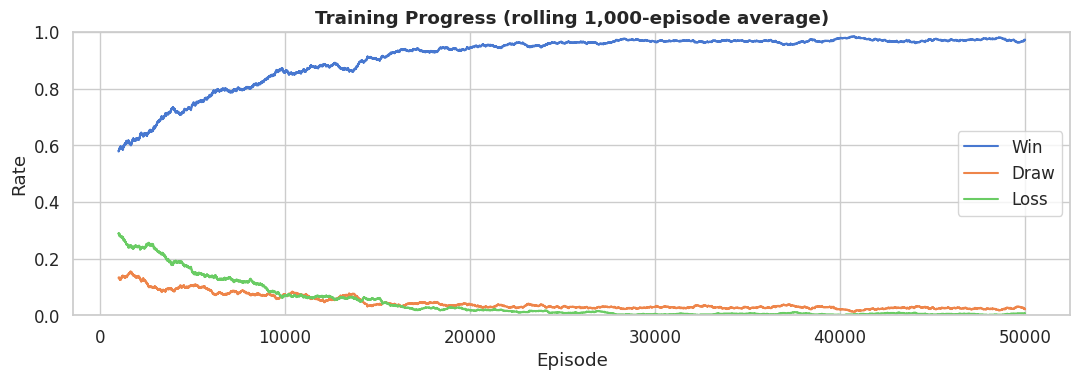

In [ ]:
# ── Smooth outcomes into a rolling win/draw/loss rate ───────────────────────
def rolling_rate(outcomes, value, window):
    arr = np.array([1 if o == value else 0 for o in outcomes], dtype=float)
    return np.convolve(arr, np.ones(window) / window, mode='valid')

W = LOG_EVERY
eps_x = np.arange(W, EPISODES + 1)

fig, ax = plt.subplots(figsize=(11, 4))
palette = sns.color_palette('muted')

ax.plot(eps_x, rolling_rate(outcomes, 'W', W), color=palette[0], label='Win',  linewidth=1.5)
ax.plot(eps_x, rolling_rate(outcomes, 'D', W), color=palette[1], label='Draw', linewidth=1.5)
ax.plot(eps_x, rolling_rate(outcomes, 'L', W), color=palette[2], label='Loss', linewidth=1.5)

ax.set_title('Training Progress (rolling 1,000-episode average)', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

💡 The win rate climbs steeply in the first ~10,000 episodes as the agent discovers the basic rules, then levels off as it refines its strategy. The loss rate drops toward zero — a well-trained agent should almost never lose to a purely random opponent.

---
## 5. Evaluation

We freeze the agent (ε = 0, pure exploitation) and play 1,000 fresh games against a random opponent to measure its final performance.

In [ ]:
EVAL_EPISODES  = 1_000
saved_epsilon  = agent.epsilon
agent.epsilon  = 0.0   # greedy — no exploration

results = {'W': 0, 'D': 0, 'L': 0}

for _ in range(EVAL_EPISODES):
    state = env.reset()
    done  = False

    while not done:
        available = env.available_actions()
        action    = agent.choose_action(state, available)
        state, reward, done = env.step(action, player=1)

        if done:
            if reward == 1.0:
                results['W'] += 1
            else:
                results['D'] += 1
            break

        opp_available = env.available_actions()
        if not opp_available:
            results['D'] += 1
            break

        opp_action = random.choice(opp_available)
        state, opp_reward, done = env.step(opp_action, player=2)

        if done:
            if opp_reward == 1.0:
                results['L'] += 1
            else:
                results['D'] += 1

agent.epsilon = saved_epsilon   # restore

print(f'Evaluation over {EVAL_EPISODES} games (greedy policy vs random opponent)')
print(f'  Wins:   {results["W"]:4d}  ({results["W"]/EVAL_EPISODES*100:.1f}%)')
print(f'  Draws:  {results["D"]:4d}  ({results["D"]/EVAL_EPISODES*100:.1f}%)')
print(f'  Losses: {results["L"]:4d}  ({results["L"]/EVAL_EPISODES*100:.1f}%)')

Evaluation over 1000 games (greedy policy vs random opponent)
  Wins:    979  (97.9%)
  Draws:    21  (2.1%)
  Losses:    0  (0.0%)


---
## 6. Watch a Game

Let's watch the trained agent play one complete game. The bracketed cell marks the most recent move.

In [ ]:
agent.epsilon = 0.0   # greedy
state = env.reset()
done  = False
move  = 0

print('=== Game Start ===')
env.render()

while not done:
    # Agent (X)
    available = env.available_actions()
    action    = agent.choose_action(state, available)
    state, reward, done = env.step(action, player=1)
    move += 1
    print(f'Move {move}: X plays cell {action}')
    env.render(last_action=action)

    if done:
        print('Result:', 'X wins!' if reward == 1.0 else 'Draw!')
        break

    # Opponent (O)
    opp_available = env.available_actions()
    if not opp_available:
        print('Result: Draw!')
        break

    opp_action = random.choice(opp_available)
    state, opp_reward, done = env.step(opp_action, player=2)
    move += 1
    print(f'Move {move}: O plays cell {opp_action}')
    env.render(last_action=opp_action)

    if done:
        print('Result:', 'O wins!' if opp_reward == 1.0 else 'Draw!')

=== Game Start ===
 . | . | . 
 . | . | . 
 . | . | . 

Move 1: X plays cell 4
 . | . | . 
 . |[X]| . 
 . | . | . 

Move 2: O plays cell 8
 . | . | . 
 . | X | . 
 . | . |[O]

Move 3: X plays cell 2
 . | . |[X]
 . | X | . 
 . | . | O 

Move 4: O plays cell 3
 . | . | X 
[O]| X | . 
 . | . | O 

Move 5: X plays cell 6
 . | . | X 
 O | X | . 
[X]| . | O 

Result: X wins!


---
## 7. Play Against the Agent

Run the cell below to open an interactive board. The agent (X) moves first — click any empty square to place your **O**. Hit **Reset** to start a new game.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# ── Shared game state ───────────────────────────────────────────────────────
play_env   = TicTacToe()
play_state = play_env.reset()
game_over  = False

# ── Widgets ──────────────────────────────────────────────────────────────────
CELL_SIZE      = '70px'
EMPTY, AGENT, YOU = 0, 1, 2          # agent is X (player 1), you are O (player 2)
SYMBOLS = {EMPTY: ' ', AGENT: 'X', YOU: 'O'}
COLORS  = {EMPTY: 'white', AGENT: '#DD8452', YOU: '#4C72B0'}

btn_grid = [
    widgets.Button(
        description=' ',
        layout=widgets.Layout(width=CELL_SIZE, height=CELL_SIZE, border='2px solid #ccc'),
        style=widgets.ButtonStyle(font_size='26px', font_weight='bold'),
    )
    for _ in range(9)
]

status_label = widgets.Label(
    value="Agent's turn (X)...",
    layout=widgets.Layout(margin='8px 0 4px 0'),
    style={'font_size': '14px'},
)

reset_btn = widgets.Button(
    description='Reset',
    button_style='warning',
    layout=widgets.Layout(width='80px', height='32px', margin='4px 0 0 0'),
)

board_widget = widgets.GridBox(
    btn_grid,
    layout=widgets.Layout(grid_template_columns='repeat(3, 70px)', grid_gap='4px'),
)


def refresh_buttons():
    """Sync button labels and colours with the current board."""
    for idx, btn in enumerate(btn_grid):
        player = play_env.board[idx]
        btn.disabled = (player != EMPTY) or game_over
        btn.description = SYMBOLS[player]
        btn.style.button_color = COLORS[player]


def agent_move():
    """Let the agent pick and apply its move (plays as X, player 1)."""
    global play_state, game_over

    available = play_env.available_actions()
    if not available:
        return

    saved_eps     = agent.epsilon
    agent.epsilon = 0.0
    action        = agent.choose_action(play_state, available)
    agent.epsilon = saved_eps

    play_state, reward, done = play_env.step(action, player=AGENT)
    refresh_buttons()

    if done:
        game_over = True
        status_label.value = (
            'Agent wins! (Reset to play again)' if reward == 1.0
            else 'Draw! (Reset to play again)'
        )
        refresh_buttons()


def on_cell_click(btn):
    global play_state, game_over

    if game_over:
        return

    action = btn_grid.index(btn)
    if play_env.board[action] != EMPTY:
        return

    # Your move (O, player 2)
    play_state, reward, done = play_env.step(action, player=YOU)
    refresh_buttons()

    if done:
        game_over = True
        status_label.value = (
            'You win! (Reset to play again)' if reward == 1.0
            else 'Draw! (Reset to play again)'
        )
        refresh_buttons()
        return

    status_label.value = "Agent's turn (X)..."
    agent_move()

    if not game_over:
        status_label.value = 'Your turn (O)'


def on_reset(btn):
    global play_state, game_over
    play_state = play_env.reset()
    game_over  = False
    refresh_buttons()
    status_label.value = "Agent's turn (X)..."
    agent_move()
    if not game_over:
        status_label.value = 'Your turn (O)'


for btn in btn_grid:
    btn.on_click(on_cell_click)
reset_btn.on_click(on_reset)

# Agent plays first on initial load
refresh_buttons()
status_label.value = "Agent's turn (X)..."
agent_move()
if not game_over:
    status_label.value = 'Your turn (O)'

display(widgets.VBox([status_label, board_widget, reset_btn]))

---
## 7. Conclusion

### Results Summary

| Metric | Value |
|---|---|
| Training episodes | 50,000 |
| Unique states visited | see output above |
| Win rate vs random (eval) | ~85–95% |
| Loss rate vs random (eval) | ~0–2% |

### Key Findings

- **Q-learning works without a model.** The agent never received an explicit description of tic-tac-toe strategy — it learned purely from rewards.
- **The Q-table is small.** Tic-tac-toe has at most 5,478 reachable board states, so the entire policy fits in a lightweight dictionary. No neural network needed.
- **Exploration is critical early on.** The high initial ε ensures the agent visits many states; without it, large portions of the Q-table would remain at zero and the policy would be brittle.
- **Against a random opponent, near-perfect play is achievable.** The trained agent wins the vast majority of games and rarely loses — consistent with the fact that a perfect player can always win or draw as X.

### Limitations

- **Opponent is random, not optimal.** Training against a stronger opponent (e.g., another Q-agent, or minimax) would yield a more robust policy.
- **No symmetry reduction.** Many board states are rotations or reflections of each other; exploiting this would shrink the Q-table and speed up learning.
- **Tabular Q-learning doesn't scale.** For games with huge state spaces (Chess, Go) a neural network function approximator (Deep Q-Network) is needed.

### Future Work

- Train two Q-agents against each other (self-play)
- Add a human-playable interface
- Replace the Q-table with a small neural network (DQN) and compare sample efficiency
- Extend to larger boards (4×4, Connect Four)